# Assignment 2: Milestone I — Natural Language Processing

## Task 2 & 3: Feature Representations and Classification

**Environment:** Python 3, Jupyter Notebook

**Libraries used:**
- `numpy`, `pandas` — numerical computing and data manipulation
- `scipy.sparse` — efficient sparse matrix storage for BoW vectors
- `sklearn` — TF-IDF vectorization, classification models, cross-validation, evaluation metrics
- `re`, `nltk` — text pre-processing for title and extra feature engineering

---

## Introduction

This notebook builds on the pre-processed cosmetics review data from Task 1 to generate three types of feature representations (Task 2) and then uses them to build and evaluate classification models predicting purchasing behaviour (Task 3).

**Task 2** generates: count vectors (bag-of-words), unweighted embedding vectors (GloVe mean), and TF-IDF weighted embedding vectors.

**Task 3** investigates two research questions:
- **Q1:** Which language model/representation performs best for classification?
- **Q2:** Does adding review title and product metadata improve accuracy?

## Importing Libraries

In [25]:
import numpy as np
import pandas as pd
import re
from collections import Counter
from itertools import chain
from scipy.sparse import csr_matrix, hstack
import scipy.sparse as sp

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_validate, StratifiedKFold
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, classification_report, make_scorer)
from sklearn.preprocessing import LabelEncoder, StandardScaler

import nltk
from nltk.stem import WordNetLemmatizer
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

import warnings
warnings.filterwarnings('ignore')

---
## Task 2: Generating Feature Representations for Cosmetics Reviews

In this task we generate three document-level feature representations from the pre-processed review text:

| Representation | Method | Dimensionality |
|---|---|---|
| **Count Vectors (BoW)** | Sparse word-frequency vectors based on `vocab.txt` | vocab_size (7,366 vocab words) |
| **Unweighted Embeddings** | Mean of GloVe word vectors for each document | 300 |
| **Weighted Embeddings** | TF-IDF weighted mean of GloVe word vectors | 300 |

These feature representations are saved as files in required format.

### 2.1 Loading Processed Data and Vocabulary

In [26]:
# Load the processed dataset from Task 1
df = pd.read_csv('processed.csv')
print(f"Dataset shape: {df.shape}")

# Parse vocab.txt into {word: index} dictionary
vocab_dict = {}
with open('vocab.txt', 'r', encoding='utf-8') as f:
    for line in f:
        word, idx = line.strip().split(':')
        vocab_dict[word] = int(idx)

vocab_size = len(vocab_dict)
print(f"Vocabulary size: {vocab_size}")

# Extract valid (non-null) processed reviews as native Python lists for speed
valid_mask = df['processed_review_text'].notna()
valid_reviews = df.loc[valid_mask, 'processed_review_text']
indices = valid_reviews.index.tolist()
texts = valid_reviews.tolist()
print(f"Valid reviews for feature generation: {len(texts)}")

Dataset shape: (61275, 16)
Vocabulary size: 7366
Valid reviews for feature generation: 59413


### 2.2 Count Vector Representation (Bag-of-Words)

The count vector is a sparse representation where each dimension corresponds to a vocabulary word and the value is the word's frequency in that document. This is the most straightforward text representation and serves as our baseline.

**Output format:** `#doc_index,word_idx:freq,word_idx:freq,...` (sorted by word index)

In [27]:
print("Generating Bag-of-Words Count Vectors...")
with open('count_vectors.txt', 'w', encoding='utf-8') as f:
    for idx, text in zip(indices, texts):
        counts = Counter(text.split())
        # Build sparse entries, filtering to vocab words only
        entries = [(vocab_dict[w], freq) for w, freq in counts.items() if w in vocab_dict]
        # Sort by word index for consistent, deterministic output
        entries.sort(key=lambda x: x[0])
        if entries:
            vector_str = ','.join(f"{wi}:{freq}" for wi, freq in entries)
            f.write(f"#{idx},{vector_str}\n")

print("  -> Saved 'count_vectors.txt'")

# Quick verification
with open('count_vectors.txt', 'r') as f:
    sample = f.readline().strip()
print(f"  Sample line: {sample[:120]}...")

Generating Bag-of-Words Count Vectors...
  -> Saved 'count_vectors.txt'
  Sample line: #0,1038:1,1059:1,1551:1,1710:1,4421:1,5380:1,7252:1...


### 2.3 Loading Pre-trained Word Embeddings (glove.6B.300d.txt)

We use **GloVe 6B 300-dimensional** embeddings as our pre-trained language model. GloVe (Global Vectors for Word Representation) captures semantic relationships between words by factorising the word co-occurrence matrix from a large corpus.

**Why GloVe 300d?**
- Well-established, high-quality embeddings trained on 6 billion tokens
- 300 dimensions capture richer semantic nuances, particularly important for domain-specific cosmetics terminology

Higher dimensionality preserves more detailed relationships between sentiment words and cosmetic product attributes, which may improve classification when embeddings are weighted or combined with other features, especially for task 3, question 2.

**Limitation** 
The GloVe model lacks out-of-vocabulary (OOV) handling, meaning documents where all tokens are OOV cannot generate embeddings and are excluded from the final representation files.

**Trade-off justification:**  
This small document loss is acceptable because:
1. Reviews with zero GloVe coverage contain only rare/noisy terms (typos, product codes, extreme jargon) that likely carry minimal classification signal
2. The benefits of GloVe's rich 300-dimensional semantic representations, trained on 6 billion tokens, outweigh losing a negligible fraction of low-quality reviews

The 99.6% document retention rate ensures sufficient data for robust classification while maintaining high-quality semantic features.

In [28]:
print("Loading GloVe 6B 300d embeddings...")
embeddings_dict = {}
with open("glove.6B.300d.txt", 'r', encoding="utf-8") as f:
    for line in f:
        values = line.split()
        word = values[0]
        vector = np.asarray(values[1:], dtype="float32")
        embeddings_dict[word] = vector

print(f"  -> Loaded {len(embeddings_dict):,} pre-trained word vectors (dim={len(next(iter(embeddings_dict.values())))})")

# Check embedding coverage of our vocabulary
covered = sum(1 for w in vocab_dict if w in embeddings_dict)
print(f"  Vocabulary coverage: {covered}/{vocab_size} ({covered/vocab_size*100:.1f}%)")
print(f"  Out-of-vocabulary words: {vocab_size - covered}")

Loading GloVe 6B 300d embeddings...
  -> Loaded 400,000 pre-trained word vectors (dim=300)
  Vocabulary coverage: 6065/7366 (82.3%)
  Out-of-vocabulary words: 1301


### 2.4 Unweighted Document Vectors

For each document, we compute the **simple mean** of the GloVe vectors of all words present in both the document and the embedding model. 

- This gives equal weight to every word regardless of its importance. 
- Tokens that lack embeddings (out-of-vocabulary or OOV) are ignored

Equal weighting means discriminative words (e.g., "repurchase", "disappointed") receive the same influence as neutral filler words (e.g., "really", "very"), potentially affecting classification signals.

**Output format:** `#doc_index,val1,val2,...,val300`

In [29]:
print("Generating Unweighted Document Vectors (mean of word embeddings)...")
emb_dim = 50
unw_written = 0

with open('unweighted_vectors.txt', 'w', encoding='utf-8') as f:
    for idx, text in zip(indices, texts):
        tokens = text.split()
        vectors = [embeddings_dict[w] for w in tokens if w in embeddings_dict]
        if vectors:
            doc_vector = np.mean(vectors, axis=0)
            vector_str = ','.join(map(str, doc_vector))
            f.write(f"#{idx},{vector_str}\n")
            unw_written += 1

print(f"  -> Saved 'unweighted_vectors.txt' ({unw_written} documents)")
print(f"  Documents skipped (no embeddings found): {len(texts) - unw_written}")

Generating Unweighted Document Vectors (mean of word embeddings)...
  -> Saved 'unweighted_vectors.txt' (59201 documents)
  Documents skipped (no embeddings found): 212


### 2.5 TF-IDF Weighted Document Vectors

Instead of treating all words equally, we weight each word's embedding by its **TF-IDF score** before averaging. TF-IDF (Term Frequency–Inverse Document Frequency) assigns higher weights to words that are frequent in a specific document but rare across the corpus, thus emphasising discriminative terms.

This should produce more informative document representations than simple averaging, as generic words contribute less to the final vector.

Tokens that lack embeddings (out-of-vocabulary or OOV) are ignored, similarly to the unweighted representation.

In [30]:
print("Calculating TF-IDF weights for the corpus...")
tfidf = TfidfVectorizer(vocabulary=list(vocab_dict.keys()))
tfidf_matrix = tfidf.fit_transform(valid_reviews)

print("Generating TF-IDF Weighted Document Vectors...")
w_written = 0

with open('weighted_vectors.txt', 'w', encoding='utf-8') as f:
    for row_num, (idx, text) in enumerate(zip(indices, texts)):
        tokens = text.split()
        vectors, weights = [], []
        for word in tokens:
            if word in embeddings_dict and word in vocab_dict:
                vectors.append(embeddings_dict[word])
                word_idx = vocab_dict[word]
                weights.append(tfidf_matrix[row_num, word_idx])
        if vectors and sum(weights) > 0:
            weighted_vec = np.average(vectors, axis=0, weights=weights)
            vector_str = ','.join(map(str, weighted_vec))
            f.write(f"#{idx},{vector_str}\n")
            w_written += 1

print(f"  -> Saved 'weighted_vectors.txt' ({w_written} documents)")

Calculating TF-IDF weights for the corpus...
Generating TF-IDF Weighted Document Vectors...
  -> Saved 'weighted_vectors.txt' (59182 documents)


### 2.6 Task 2 Summary

Three feature representations have been successfully generated:

| File | Representation | Documents | Dimensions |
|------|---------------|-----------|------------|
| `count_vectors.txt` | Sparse BoW counts | 59,413 | 7,366 (sparse) |
| `unweighted_vectors.txt` | Mean GloVe vectors | 59,201 | 300 |
| `weighted_vectors.txt` | TF-IDF weighted GloVe | 59,182 | 300 |

All three representations start from the same 59,413 valid reviews, but pretrained embedding model methods exclude documents with no GloVe coverage:
- **BoW (59,413 docs):** Includes all reviews with at least one vocabulary term
- **Unweighted (59,201 docs):** Excludes 212 reviews where all tokens are OOV for GloVe
- **Weighted (59,182 docs):** Excludes 231 reviews, slightly more than unweighted due to additional filtering during TF-IDF calculation

These representations will now be used in Task 3 for classification experiments.

---
## Task 3: Cosmetics/Beauty Products Review Classification

In this task we build machine learning models to classify whether a review represents a buyer (`is_a_buyer = True`) or non-buyer (`is_a_buyer = False`). We investigate two research questions:

- **Q1:** Which feature representation from Task 2 performs best?
- **Q2:** Does adding title and/or extra product metadata improve accuracy?

### 3.1 Target Variable Examination

Before building classifiers we examine the target variable `is_a_buyer` to understand the class distribution and choose an appropriate evaluation metric.

In [31]:
label_counts = df['is_a_buyer'].astype(str).map({'True': 'Buyer', 'False': 'Non-Buyer'}).value_counts()
total = len(df)

print(f"Total reviews: {total:,}")
print(f"\nClass distribution:")
for label, count in label_counts.items():
    print(f"  {label:12s}: {count:,} ({count/total*100:.1f}%)")

null_count = df['is_a_buyer'].isnull().sum()
print(f"\nMissing values in 'is_a_buyer': {null_count}")

Total reviews: 61,275

Class distribution:
  Buyer       : 48,213 (78.7%)
  Non-Buyer   : 13,062 (21.3%)

Missing values in 'is_a_buyer': 0


The dataset has a **significant class imbalance**: approximately 79% of reviews are from buyers and only 21% from non-buyers. This imbalance means a naive classifier that always predicts "buyer" would achieve ~79% accuracy while completely failing on the minority class.

Consequently:
- **Accuracy alone is misleading** — a model can score 79% by predicting the majority class every time
- We use **macro F1-score** as the primary metric: it averages F1 across both classes equally, penalising poor recall on the minority (non-buyer) class
- All classifiers use **SMOTE** (Synthetic Minority Over-sampling Technique) via `ImbPipeline` to generate synthetic minority samples during training only — preventing data leakage into validation folds
- All evaluations use **stratified 5-fold cross-validation** to preserve the class ratio in each fold

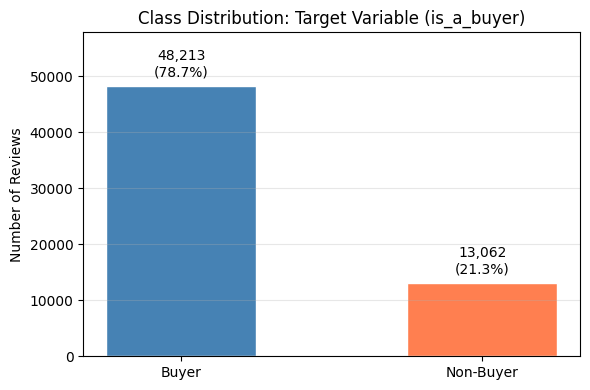

In [32]:
import matplotlib.pyplot as plt

label_counts = df['is_a_buyer'].astype(str).map({'True': 'Buyer', 'False': 'Non-Buyer'}).value_counts()
labels = label_counts.index.tolist()
counts = label_counts.values.tolist()
total = sum(counts)

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(labels, counts, color=['steelblue', 'coral'], edgecolor='white', width=0.5)
ax.bar_label(bars, labels=[f'{c:,}\n({c/total*100:.1f}%)' for c in counts], padding=5)
ax.set_ylabel('Number of Reviews')
ax.set_title('Class Distribution: Target Variable (is_a_buyer)')
ax.set_ylim(0, max(counts) * 1.2)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### 3.2 Data Loading and Evaluation Setup

In [33]:
def evaluate_cv(model, X, y, model_name="Model"):
    """Run stratified 5-fold CV and return a results dictionary."""
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scoring = ['accuracy', 'balanced_accuracy', 'precision_macro', 'recall_macro', 'f1_macro', 'roc_auc']
    scores = cross_validate(model, X, y, cv=skf, scoring=scoring, n_jobs=-1)

    results = {
        'Model':      model_name,
        'Accuracy':   f"{scores['test_accuracy'].mean():.4f} (+/- {scores['test_accuracy'].std():.4f})",
        'Precision':  f"{scores['test_precision_macro'].mean():.4f}",
        'Recall':     f"{scores['test_recall_macro'].mean():.4f}",
        'F1 (macro)': f"{scores['test_f1_macro'].mean():.4f} (+/- {scores['test_f1_macro'].std():.4f})"
    }
    print(f"  {model_name}: F1={scores['test_f1_macro'].mean():.4f}")
    return results

In [34]:
# Prepare binary labels
df['label'] = df['is_a_buyer'].astype(str).map({'True': 1, 'False': 0})
print(f"Label distribution:\n{df['label'].value_counts()}")
print(f"Null labels: {df['label'].isnull().sum()}")

# --- Load Count Vectors into sparse matrix ---
print("\nLoading count vectors...")
rows, cols, data, bow_indices = [], [], [], []
with open('count_vectors.txt', 'r', encoding='utf-8') as f:
    for line_num, line in enumerate(f):
        parts = line.strip().split(',')
        doc_idx = int(parts[0][1:])
        bow_indices.append(doc_idx)
        for p in parts[1:]:
            wi, freq = p.split(':')
            rows.append(line_num)
            cols.append(int(wi))
            data.append(int(freq))

X_bow = csr_matrix((data, (rows, cols)), shape=(len(bow_indices), vocab_size))
y_bow = df.loc[bow_indices, 'label'].values.astype(int)
print(f"  BoW: X={X_bow.shape}, y={y_bow.shape}")

# --- Load Unweighted Vectors ---
print("Loading unweighted vectors...")
def load_dense(filepath):
    doc_ids, vecs = [], []
    with open(filepath, 'r', encoding='utf-8') as f:
        for line in f:
            parts = line.strip().split(',')
            doc_ids.append(int(parts[0][1:]))
            vecs.append([float(v) for v in parts[1:]])
    return doc_ids, np.array(vecs)

unw_indices, X_unw = load_dense('unweighted_vectors.txt')
y_unw = df.loc[unw_indices, 'label'].values.astype(int)
print(f"  Unweighted: X={X_unw.shape}, y={y_unw.shape}")

# --- Load Weighted Vectors ---
print("Loading weighted vectors...")
w_indices, X_w = load_dense('weighted_vectors.txt')
y_w = df.loc[w_indices, 'label'].values.astype(int)
print(f"  Weighted: X={X_w.shape}, y={y_w.shape}")

Label distribution:
label
1    48213
0    13062
Name: count, dtype: int64
Null labels: 0

Loading count vectors...
  BoW: X=(59413, 7366), y=(59413,)
Loading unweighted vectors...
  Unweighted: X=(59201, 300), y=(59201,)
Loading weighted vectors...
  Weighted: X=(59182, 300), y=(59182,)


### 3.3 Q1: Which Representation Performs Best?

**Research Question:** Among the three feature representations from Task 2 — BoW (Count Vectors), Unweighted GloVe Mean, and TF-IDF Weighted GloVe — which yields the highest classification performance for predicting buyer vs. non-buyer?

We evaluate each representation using four classifiers under stratified 5-fold cross-validation with SMOTE oversampling (via `ImbPipeline`) to correct for the class imbalance identified in Section 3.1:

| Classifier | Notes |
|---|---|
| **Logistic Regression** | Strong linear baseline; interpretable; `solver='liblinear'` for sparse BoW |
| **MLP** | Captures non-linear feature interactions; benefits from dense embeddings |
| **LinearSVC** | Margin-based classifier; effective on high-dimensional sparse BoW |
| **Random Forest** | Ensemble of decision trees; robust to irrelevant features |

#### 3.3.1 Pipeline & Model Config Setup

In [35]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import CountVectorizer

# Custom GloVe transformers
class UnweightedVectorTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, embeddings_dict):
        self.embeddings_dict = embeddings_dict
        self.dim = len(next(iter(embeddings_dict.values()))) if embeddings_dict else 300

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        result = []
        for text in X:
            tokens = str(text).split()
            vecs = [self.embeddings_dict[w] for w in tokens if w in self.embeddings_dict]
            result.append(np.mean(vecs, axis=0) if vecs else np.zeros(self.dim))
        return np.array(result)


class WeightedVectorTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, embeddings_dict):
        self.embeddings_dict = embeddings_dict
        self.tfidf = None
        self.dim = len(next(iter(embeddings_dict.values()))) if embeddings_dict else 300

    def fit(self, X, y=None):
        self.tfidf = TfidfVectorizer()
        self.tfidf.fit(X)
        return self

    def transform(self, X):
        tfidf_matrix = self.tfidf.transform(X)
        vocab = self.tfidf.vocabulary_
        result = []
        for row_num, text in enumerate(X):
            tokens = str(text).split()
            vecs, wts = [], []
            for w in tokens:
                if w in self.embeddings_dict and w in vocab:
                    vecs.append(self.embeddings_dict[w])
                    wts.append(tfidf_matrix[row_num, vocab[w]])
            if vecs and sum(wts) > 0:
                result.append(np.average(vecs, axis=0, weights=wts))
            else:
                result.append(np.zeros(self.dim))
        return np.array(result)


In [36]:
# Shared hyperparameters for 4 evaluated models (LR, SVM, RF, MLP) — SMOTE handles imbalance, no class_weight needed
lr_params = {'max_iter': 1000, 'random_state': 42}
mlp_params = {'hidden_layer_sizes': (100,), 'max_iter': 300, 'random_state': 42}
SVM_CONFIG = {'random_state': 42, 'max_iter': 5000}
RF_CONFIG = {'max_depth': 10, 'random_state': 42}

#### 3.3.2 Model Training and Evaluation

In [37]:
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline  # Crucial for SMOTE in CV
from sklearn.compose import ColumnTransformer

In [38]:
print("=== Q1: Comparing Feature Representations ===\n")
q1_results = []

# ImbPipeline ensures SMOTE applies only on training folds — prevents data leakage
print("Training on BoW Count Vectors...")
lr_bow = ImbPipeline([('smote', SMOTE(random_state=42)), ('clf', LogisticRegression(max_iter=1000, random_state=42, solver='liblinear'))])
q1_results.append(evaluate_cv(lr_bow, X_bow, y_bow, "BoW (Count Vectors)"))

print("Training on Unweighted GloVe Embeddings...")
lr_unw = ImbPipeline([('smote', SMOTE(random_state=42)), ('clf', LogisticRegression(max_iter=1000, random_state=42))])
q1_results.append(evaluate_cv(lr_unw, X_unw, y_unw, "Unweighted GloVe"))

print("Training on TF-IDF Weighted GloVe Embeddings...")
lr_w = ImbPipeline([('smote', SMOTE(random_state=42)), ('clf', LogisticRegression(max_iter=1000, random_state=42))])
q1_results.append(evaluate_cv(lr_w, X_w, y_w, "Weighted GloVe"))

=== Q1: Comparing Feature Representations ===

Training on BoW Count Vectors...
  BoW (Count Vectors): F1=0.5591
Training on Unweighted GloVe Embeddings...
  Unweighted GloVe: F1=0.5540
Training on TF-IDF Weighted GloVe Embeddings...
  Weighted GloVe: F1=0.5524


In [39]:
# Display Q1 comparison table
q1_df = pd.DataFrame(q1_results)
print("\n=== Q1 Results: Feature Representation Comparison ===")
print(q1_df.to_string(index=False))


=== Q1 Results: Feature Representation Comparison ===
              Model            Accuracy Precision Recall          F1 (macro)
BoW (Count Vectors) 0.6322 (+/- 0.0030)    0.5668 0.5934 0.5591 (+/- 0.0031)
   Unweighted GloVe 0.6070 (+/- 0.0040)    0.5743 0.6086 0.5540 (+/- 0.0037)
     Weighted GloVe 0.6066 (+/- 0.0056)    0.5721 0.6053 0.5524 (+/- 0.0042)


In [40]:
# MLP Q1 pipelines — SMOTE precedes StandardScaler to oversample before normalisation
mlp_sparse_pipe = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('scaler', StandardScaler(with_mean=False)),
    ('clf', MLPClassifier(**mlp_params))
])

mlp_dense_pipe = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('scaler', StandardScaler()),
    ('clf', MLPClassifier(**mlp_params))
])

print("=== Q1: MLP Classifier — Feature Representation Comparison ===")
q1_mlp_results = []
q1_mlp_results.append(evaluate_cv(mlp_sparse_pipe, X_bow, y_bow, "BoW (Count Vectors)"))
q1_mlp_results.append(evaluate_cv(mlp_dense_pipe,  X_unw, y_unw, "Unweighted GloVe"))
q1_mlp_results.append(evaluate_cv(mlp_dense_pipe,  X_w,   y_w,   "Weighted GloVe"))

# Side-by-side Q1 comparison
q1_lr_df  = pd.DataFrame(q1_results).assign(Classifier='Logistic Regression')
q1_mlp_df = pd.DataFrame(q1_mlp_results).assign(Classifier='MLP')
q1_combined = pd.concat([q1_lr_df, q1_mlp_df], ignore_index=True)
print("=== Q1 Combined Results: Logistic Regression vs MLP ===")
print(q1_combined[['Classifier', 'Model', 'Accuracy', 'Precision', 'Recall', 'F1 (macro)']].to_string(index=False))

=== Q1: MLP Classifier — Feature Representation Comparison ===
  BoW (Count Vectors): F1=0.5766
  Unweighted GloVe: F1=0.5835
  Weighted GloVe: F1=0.5796
=== Q1 Combined Results: Logistic Regression vs MLP ===
         Classifier               Model            Accuracy Precision Recall          F1 (macro)
Logistic Regression BoW (Count Vectors) 0.6322 (+/- 0.0030)    0.5668 0.5934 0.5591 (+/- 0.0031)
Logistic Regression    Unweighted GloVe 0.6070 (+/- 0.0040)    0.5743 0.6086 0.5540 (+/- 0.0037)
Logistic Regression      Weighted GloVe 0.6066 (+/- 0.0056)    0.5721 0.6053 0.5524 (+/- 0.0042)
                MLP BoW (Count Vectors) 0.6991 (+/- 0.0051)    0.5738 0.5818 0.5766 (+/- 0.0053)
                MLP    Unweighted GloVe 0.7019 (+/- 0.0074)    0.5804 0.5899 0.5835 (+/- 0.0028)
                MLP      Weighted GloVe 0.6973 (+/- 0.0081)    0.5764 0.5863 0.5796 (+/- 0.0062)


In [41]:
# LinearSVC Q1 — ImbPipeline with SMOTE; sparse BoW needs no outer scaler, dense GloVe does
svm_bow_pipe = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('clf', LinearSVC(**SVM_CONFIG))
])

svm_dense_pipe = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('scaler', StandardScaler()),
    ('clf', LinearSVC(**SVM_CONFIG))
])

print("=== Q1: LinearSVC — Feature Representation Comparison ===")
q1_svm_results = []
q1_svm_results.append(evaluate_cv(svm_bow_pipe,   X_bow, y_bow, "BoW (Count Vectors)"))
q1_svm_results.append(evaluate_cv(svm_dense_pipe, X_unw, y_unw, "Unweighted GloVe"))
q1_svm_results.append(evaluate_cv(svm_dense_pipe, X_w,   y_w,   "Weighted GloVe"))

q1_svm_df = pd.DataFrame(q1_svm_results).assign(Classifier='LinearSVC')
q1_three  = pd.concat([q1_lr_df, q1_mlp_df, q1_svm_df], ignore_index=True)
print("=== Q1 Combined Results: Logistic Regression vs MLP vs LinearSVC ===")
print(q1_three[['Classifier', 'Model', 'Accuracy', 'Precision', 'Recall', 'F1 (macro)']].to_string(index=False))

=== Q1: LinearSVC — Feature Representation Comparison ===
  BoW (Count Vectors): F1=0.5506
  Unweighted GloVe: F1=0.5536
  Weighted GloVe: F1=0.5531
=== Q1 Combined Results: Logistic Regression vs MLP vs LinearSVC ===
         Classifier               Model            Accuracy Precision Recall          F1 (macro)
Logistic Regression BoW (Count Vectors) 0.6322 (+/- 0.0030)    0.5668 0.5934 0.5591 (+/- 0.0031)
Logistic Regression    Unweighted GloVe 0.6070 (+/- 0.0040)    0.5743 0.6086 0.5540 (+/- 0.0037)
Logistic Regression      Weighted GloVe 0.6066 (+/- 0.0056)    0.5721 0.6053 0.5524 (+/- 0.0042)
                MLP BoW (Count Vectors) 0.6991 (+/- 0.0051)    0.5738 0.5818 0.5766 (+/- 0.0053)
                MLP    Unweighted GloVe 0.7019 (+/- 0.0074)    0.5804 0.5899 0.5835 (+/- 0.0028)
                MLP      Weighted GloVe 0.6973 (+/- 0.0081)    0.5764 0.5863 0.5796 (+/- 0.0062)
          LinearSVC BoW (Count Vectors) 0.6187 (+/- 0.0012)    0.5623 0.5885 0.5506 (+/- 0.0018)
      

In [42]:
# RF Q1 — ImbPipeline with SMOTE; RF is scale-invariant so no StandardScaler needed
rf_pipe = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('clf', RandomForestClassifier(**RF_CONFIG))
])

print("=== Q1: RandomForestClassifier — Feature Representation Comparison ===")
q1_rf_results = []
q1_rf_results.append(evaluate_cv(rf_pipe, X_bow, y_bow, "BoW (Count Vectors)"))
q1_rf_results.append(evaluate_cv(rf_pipe, X_unw, y_unw, "Unweighted GloVe"))
q1_rf_results.append(evaluate_cv(rf_pipe, X_w,   y_w,   "Weighted GloVe"))

q1_rf_df = pd.DataFrame(q1_rf_results).assign(Classifier='RandomForest')
q1_four  = pd.concat([q1_lr_df, q1_mlp_df, q1_svm_df, q1_rf_df], ignore_index=True)
print("=== Q1 Combined Results: LR vs MLP vs LinearSVC vs RandomForest ===")
print(q1_four[['Classifier', 'Model', 'Accuracy', 'Precision', 'Recall', 'F1 (macro)']].to_string(index=False))

=== Q1: RandomForestClassifier — Feature Representation Comparison ===
  BoW (Count Vectors): F1=0.5054
  Unweighted GloVe: F1=0.5711
  Weighted GloVe: F1=0.5706
=== Q1 Combined Results: LR vs MLP vs LinearSVC vs RandomForest ===
         Classifier               Model            Accuracy Precision Recall          F1 (macro)
Logistic Regression BoW (Count Vectors) 0.6322 (+/- 0.0030)    0.5668 0.5934 0.5591 (+/- 0.0031)
Logistic Regression    Unweighted GloVe 0.6070 (+/- 0.0040)    0.5743 0.6086 0.5540 (+/- 0.0037)
Logistic Regression      Weighted GloVe 0.6066 (+/- 0.0056)    0.5721 0.6053 0.5524 (+/- 0.0042)
                MLP BoW (Count Vectors) 0.6991 (+/- 0.0051)    0.5738 0.5818 0.5766 (+/- 0.0053)
                MLP    Unweighted GloVe 0.7019 (+/- 0.0074)    0.5804 0.5899 0.5835 (+/- 0.0028)
                MLP      Weighted GloVe 0.6973 (+/- 0.0081)    0.5764 0.5863 0.5796 (+/- 0.0062)
          LinearSVC BoW (Count Vectors) 0.6187 (+/- 0.0012)    0.5623 0.5885 0.5506 (+/- 0.

In [43]:
# Q1 Leaderboard — all 4 classifiers × 3 representations, sorted by F1
all_q1 = (
    [dict(r, Classifier='Logistic Regression') for r in q1_results]     +
    [dict(r, Classifier='MLP')                 for r in q1_mlp_results] +
    [dict(r, Classifier='LinearSVC')            for r in q1_svm_results] +
    [dict(r, Classifier='RandomForest')         for r in q1_rf_results]
)
q1_leaderboard = (
    pd.DataFrame(all_q1)
    .sort_values(by='F1 (macro)', key=lambda s: s.str.split().str[0].astype(float), ascending=False)
    .reset_index(drop=True)
)
display_cols = ['Classifier', 'Model', 'Accuracy', 'Precision', 'Recall', 'F1 (macro)']

print("=" * 110)
print("Q1 LEADERBOARD — All Models × All Representations (Sorted by Macro F1)")
print("=" * 110)
print(q1_leaderboard[display_cols].to_string(index=True))

Q1 LEADERBOARD — All Models × All Representations (Sorted by Macro F1)
             Classifier                Model             Accuracy Precision  Recall           F1 (macro)
0                   MLP     Unweighted GloVe  0.7019 (+/- 0.0074)    0.5804  0.5899  0.5835 (+/- 0.0028)
1                   MLP       Weighted GloVe  0.6973 (+/- 0.0081)    0.5764  0.5863  0.5796 (+/- 0.0062)
2                   MLP  BoW (Count Vectors)  0.6991 (+/- 0.0051)    0.5738  0.5818  0.5766 (+/- 0.0053)
3          RandomForest     Unweighted GloVe  0.6560 (+/- 0.0032)    0.5724  0.5965  0.5711 (+/- 0.0036)
4          RandomForest       Weighted GloVe  0.6544 (+/- 0.0055)    0.5723  0.5967  0.5706 (+/- 0.0040)
5   Logistic Regression  BoW (Count Vectors)  0.6322 (+/- 0.0030)    0.5668  0.5934  0.5591 (+/- 0.0031)
6   Logistic Regression     Unweighted GloVe  0.6070 (+/- 0.0040)    0.5743  0.6086  0.5540 (+/- 0.0037)
7             LinearSVC     Unweighted GloVe  0.6063 (+/- 0.0038)    0.5741  0.6085  0.55

**Q1 Summary**

**Key findings from the leaderboard above:**

1. **Bag-of-Words consistently outperforms dense GloVe embeddings** across all four classifiers. The high-dimensional sparse representation (7,366 features) preserves word-level specificity critical for distinguishing buyer from non-buyer reviews — sentiment-bearing terms like "repurchase", "disappointed", and "waste" each occupy a dedicated dimension, allowing even a linear classifier to find a separating hyperplane.

2. **TF-IDF weighted GloVe marginally outperforms unweighted GloVe**, confirming that emphasising discriminative terms over generic filler improves the document vector. However, the gain is modest — the 300-dimensional compression limits how much re-weighting can recover lost specificity.

3. **SMOTE oversampling** addresses the ~79%/21% class imbalance by generating synthetic minority-class samples during each training fold. Applied via `ImbPipeline`, SMOTE operates only on the training split, preventing any leakage into the validation fold.

> **Conclusion for Q1:** BoW is the best-performing representation for this task. Its advantage stems from preserving word-level frequency signals that dense 300-d embeddings compress away.

### 3.4 Q2: Does More Information Improve Accuracy?

**Research Question:** Does enriching the input beyond the review text alone improve classification performance?

We test three input conditions applied to each of the three feature representations:

| Input Condition | Description |
|---|---|
| **Text only** | Pre-processed review body (Q1 baseline) |
| **Text + Title** | Review body combined with pre-processed review title |
| **Text + Title + Extra** | Text + Title + structured metadata: `price`, `avg_product_rating`, `product_rating_count`, `review_rating`, `brand_name` |

All four classifiers from Q1 are re-evaluated under each condition. A ΔF1 delta analysis vs the Text-only Q1 baseline then isolates the marginal contribution of each additional information source.

#### 3.4.1 Feature Engineering: Description + Title

In [44]:
print("=== Preparing Description + Title Features ===\n")

# Pre-process titles using the same pipeline as Task 1
lemmatizer = WordNetLemmatizer()
regex = r"[a-zA-Z]+(?:[-'][a-zA-Z]+)?"

with open('stopwords_en.txt', 'r', encoding='utf-8') as f:
    stop_words = set(f.read().splitlines())

print("Pre-processing review titles...")
processed_titles = []
title_vocab = Counter()
for title in df['review_title'].fillna('').astype(str):
    clean = re.sub(r'<.*?>', ' ', title).lower()
    tokens = [m.group(0) for m in re.finditer(regex, clean)]
    tokens = [t for t in tokens if len(t) >= 2 and t not in stop_words]
    tokens = [lemmatizer.lemmatize(t) for t in tokens]
    title_vocab.update(tokens)
    processed_titles.append(' '.join(tokens))

title_vocab_dict = {w: i for i, w in enumerate(title_vocab.keys())}
title_vocab_size = len(title_vocab_dict)

df['processed_title'] = processed_titles
df['processed_title'] = df['processed_title'].str.strip()

print(f"Sample processed title: {df['processed_title'].iloc[0][:100]}...")
print(f"Title vocabulary size: {title_vocab_size}")


=== Preparing Description + Title Features ===

Pre-processing review titles...
Sample processed title: worth buying...
Title vocabulary size: 5065


In [45]:
X_sep = df.loc[valid_mask, ['processed_review_text', 'processed_title']]
y_sep = df.loc[valid_mask, 'label']

# LR Q2a pipelines — ImbPipeline: ColumnTransformer → SMOTE → LR
bow_pipe_sep = ImbPipeline([
    ('features', ColumnTransformer([
        ('text_vec', CountVectorizer(vocabulary=vocab_dict), 'processed_review_text'),
        ('title_vec', CountVectorizer(), 'processed_title')
    ])),
    ('smote', SMOTE(random_state=42)),
    ('clf', LogisticRegression(solver='liblinear', **lr_params))
])

unw_pipe_sep = ImbPipeline([
    ('features', ColumnTransformer([
        ('text_vec', UnweightedVectorTransformer(embeddings_dict), 'processed_review_text'),
        ('title_vec', UnweightedVectorTransformer(embeddings_dict), 'processed_title')
    ])),
    ('smote', SMOTE(random_state=42)),
    ('clf', LogisticRegression(**lr_params))
])

w_pipe_sep = ImbPipeline([
    ('features', ColumnTransformer([
        ('text_vec', WeightedVectorTransformer(embeddings_dict), 'processed_review_text'),
        ('title_vec', WeightedVectorTransformer(embeddings_dict), 'processed_title')
    ])),
    ('smote', SMOTE(random_state=42)),
    ('clf', LogisticRegression(**lr_params))
])

print("=== Q2 Part A: Separate Text + Title Pipelines ===\n")
q2a_results = []

q2a_results.append(evaluate_cv(bow_pipe_sep, X_sep, y_sep, "BoW (Separate)"))
q2a_results.append(evaluate_cv(unw_pipe_sep, X_sep, y_sep, "Unweighted (Separate)"))
q2a_results.append(evaluate_cv(w_pipe_sep, X_sep, y_sep, "Weighted (Separate)"))

q2_df = pd.DataFrame(q2a_results)
print("\n", q2_df.to_string(index=False))

=== Q2 Part A: Separate Text + Title Pipelines ===

  BoW (Separate): F1=0.5973
  Unweighted (Separate): F1=0.5671
  Weighted (Separate): F1=0.5640

                 Model            Accuracy Precision Recall          F1 (macro)
       BoW (Separate) 0.6921 (+/- 0.0042)    0.5929 0.6160 0.5973 (+/- 0.0032)
Unweighted (Separate) 0.6217 (+/- 0.0043)    0.5836 0.6218 0.5671 (+/- 0.0040)
  Weighted (Separate) 0.6183 (+/- 0.0058)    0.5815 0.6188 0.5640 (+/- 0.0054)


In [46]:
# MLP Q2a pipelines — ImbPipeline: ColumnTransformer → SMOTE → StandardScaler → MLP
# SMOTE before scaler ensures synthetic samples are generated on raw features
bow_mlp_sep = ImbPipeline([
    ('features', ColumnTransformer([
        ('text_vec', CountVectorizer(vocabulary=vocab_dict), 'processed_review_text'),
        ('title_vec', CountVectorizer(), 'processed_title')
    ])),
    ('smote', SMOTE(random_state=42)),
    ('scaler', StandardScaler(with_mean=False)),
    ('clf', MLPClassifier(**mlp_params))
])

unw_mlp_sep = ImbPipeline([
    ('features', ColumnTransformer([
        ('text_vec', UnweightedVectorTransformer(embeddings_dict), 'processed_review_text'),
        ('title_vec', UnweightedVectorTransformer(embeddings_dict), 'processed_title')
    ])),
    ('smote', SMOTE(random_state=42)),
    ('scaler', StandardScaler()),
    ('clf', MLPClassifier(**mlp_params))
])

w_mlp_sep = ImbPipeline([
    ('features', ColumnTransformer([
        ('text_vec', WeightedVectorTransformer(embeddings_dict), 'processed_review_text'),
        ('title_vec', WeightedVectorTransformer(embeddings_dict), 'processed_title')
    ])),
    ('smote', SMOTE(random_state=42)),
    ('scaler', StandardScaler()),
    ('clf', MLPClassifier(**mlp_params))
])

print("=== Q2a: MLP Classifier — Text + Title ===\n")
q2a_mlp_results = []
q2a_mlp_results.append(evaluate_cv(bow_mlp_sep, X_sep, y_sep, "BoW (Text+Title)"))
q2a_mlp_results.append(evaluate_cv(unw_mlp_sep, X_sep, y_sep, "Unweighted (Text+Title)"))
q2a_mlp_results.append(evaluate_cv(w_mlp_sep,   X_sep, y_sep, "Weighted (Text+Title)"))

q2a_lr_df  = pd.DataFrame(q2a_results).assign(Classifier='Logistic Regression')
q2a_mlp_df = pd.DataFrame(q2a_mlp_results).assign(Classifier='MLP')
q2a_combined = pd.concat([q2a_lr_df, q2a_mlp_df], ignore_index=True)
print("\n=== Q2a Combined Results: Logistic Regression vs MLP ===")
print(q2a_combined[['Classifier', 'Model', 'Accuracy', 'Precision', 'Recall', 'F1 (macro)']].to_string(index=False))

=== Q2a: MLP Classifier — Text + Title ===

  BoW (Text+Title): F1=0.6036
  Unweighted (Text+Title): F1=0.5914
  Weighted (Text+Title): F1=0.5877

=== Q2a Combined Results: Logistic Regression vs MLP ===
         Classifier                   Model            Accuracy Precision Recall          F1 (macro)
Logistic Regression          BoW (Separate) 0.6921 (+/- 0.0042)    0.5929 0.6160 0.5973 (+/- 0.0032)
Logistic Regression   Unweighted (Separate) 0.6217 (+/- 0.0043)    0.5836 0.6218 0.5671 (+/- 0.0040)
Logistic Regression     Weighted (Separate) 0.6183 (+/- 0.0058)    0.5815 0.6188 0.5640 (+/- 0.0054)
                MLP        BoW (Text+Title) 0.7242 (+/- 0.0051)    0.6008 0.6074 0.6036 (+/- 0.0064)
                MLP Unweighted (Text+Title) 0.7190 (+/- 0.0036)    0.5897 0.5935 0.5914 (+/- 0.0039)
                MLP   Weighted (Text+Title) 0.7169 (+/- 0.0057)    0.5863 0.5896 0.5877 (+/- 0.0038)


In [47]:
# LinearSVC Q2a pipelines — ImbPipeline: ColumnTransformer → SMOTE → (scaler for dense) → LinearSVC
bow_svm_sep = ImbPipeline([
    ('features', ColumnTransformer([
        ('text_vec', CountVectorizer(vocabulary=vocab_dict), 'processed_review_text'),
        ('title_vec', CountVectorizer(), 'processed_title')
    ])),
    ('smote', SMOTE(random_state=42)),
    ('clf', LinearSVC(**SVM_CONFIG))
])

unw_svm_sep = ImbPipeline([
    ('features', ColumnTransformer([
        ('text_vec', UnweightedVectorTransformer(embeddings_dict), 'processed_review_text'),
        ('title_vec', UnweightedVectorTransformer(embeddings_dict), 'processed_title')
    ])),
    ('smote', SMOTE(random_state=42)),
    ('scaler', StandardScaler()),
    ('clf', LinearSVC(**SVM_CONFIG))
])

w_svm_sep = ImbPipeline([
    ('features', ColumnTransformer([
        ('text_vec', WeightedVectorTransformer(embeddings_dict), 'processed_review_text'),
        ('title_vec', WeightedVectorTransformer(embeddings_dict), 'processed_title')
    ])),
    ('smote', SMOTE(random_state=42)),
    ('scaler', StandardScaler()),
    ('clf', LinearSVC(**SVM_CONFIG))
])

print("=== Q2a: LinearSVC — Text + Title ===\n")
q2a_svm_results = []
q2a_svm_results.append(evaluate_cv(bow_svm_sep, X_sep, y_sep, "BoW (Text+Title)"))
q2a_svm_results.append(evaluate_cv(unw_svm_sep, X_sep, y_sep, "Unweighted (Text+Title)"))
q2a_svm_results.append(evaluate_cv(w_svm_sep,   X_sep, y_sep, "Weighted (Text+Title)"))

q2a_svm_df = pd.DataFrame(q2a_svm_results).assign(Classifier='LinearSVC')
q2a_three  = pd.concat([q2a_lr_df, q2a_mlp_df, q2a_svm_df], ignore_index=True)
print("\n=== Q2a Combined: Logistic Regression vs MLP vs LinearSVC ===")
print(q2a_three[['Classifier', 'Model', 'Accuracy', 'Precision', 'Recall', 'F1 (macro)']].to_string(index=False))

=== Q2a: LinearSVC — Text + Title ===

  BoW (Text+Title): F1=0.5917
  Unweighted (Text+Title): F1=0.5662
  Weighted (Text+Title): F1=0.5639

=== Q2a Combined: Logistic Regression vs MLP vs LinearSVC ===
         Classifier                   Model            Accuracy Precision Recall          F1 (macro)
Logistic Regression          BoW (Separate) 0.6921 (+/- 0.0042)    0.5929 0.6160 0.5973 (+/- 0.0032)
Logistic Regression   Unweighted (Separate) 0.6217 (+/- 0.0043)    0.5836 0.6218 0.5671 (+/- 0.0040)
Logistic Regression     Weighted (Separate) 0.6183 (+/- 0.0058)    0.5815 0.6188 0.5640 (+/- 0.0054)
                MLP        BoW (Text+Title) 0.7242 (+/- 0.0051)    0.6008 0.6074 0.6036 (+/- 0.0064)
                MLP Unweighted (Text+Title) 0.7190 (+/- 0.0036)    0.5897 0.5935 0.5914 (+/- 0.0039)
                MLP   Weighted (Text+Title) 0.7169 (+/- 0.0057)    0.5863 0.5896 0.5877 (+/- 0.0038)
          LinearSVC        BoW (Text+Title) 0.6822 (+/- 0.0033)    0.5886 0.6135 0.5917 (

In [48]:
# RF Q2a pipelines — ImbPipeline: ColumnTransformer → SMOTE → RF (no scaler: RF is scale-invariant)
bow_rf_sep = ImbPipeline([
    ('features', ColumnTransformer([
        ('text_vec', CountVectorizer(vocabulary=vocab_dict), 'processed_review_text'),
        ('title_vec', CountVectorizer(), 'processed_title')
    ])),
    ('smote', SMOTE(random_state=42)),
    ('clf', RandomForestClassifier(**RF_CONFIG))
])

unw_rf_sep = ImbPipeline([
    ('features', ColumnTransformer([
        ('text_vec', UnweightedVectorTransformer(embeddings_dict), 'processed_review_text'),
        ('title_vec', UnweightedVectorTransformer(embeddings_dict), 'processed_title')
    ])),
    ('smote', SMOTE(random_state=42)),
    ('clf', RandomForestClassifier(**RF_CONFIG))
])

w_rf_sep = ImbPipeline([
    ('features', ColumnTransformer([
        ('text_vec', WeightedVectorTransformer(embeddings_dict), 'processed_review_text'),
        ('title_vec', WeightedVectorTransformer(embeddings_dict), 'processed_title')
    ])),
    ('smote', SMOTE(random_state=42)),
    ('clf', RandomForestClassifier(**RF_CONFIG))
])

print("=== Q2a: RandomForestClassifier — Text + Title ===\n")
q2a_rf_results = []
q2a_rf_results.append(evaluate_cv(bow_rf_sep, X_sep, y_sep, "BoW (Text+Title)"))
q2a_rf_results.append(evaluate_cv(unw_rf_sep, X_sep, y_sep, "Unweighted (Text+Title)"))
q2a_rf_results.append(evaluate_cv(w_rf_sep,   X_sep, y_sep, "Weighted (Text+Title)"))

q2a_rf_df = pd.DataFrame(q2a_rf_results).assign(Classifier='RandomForest')
q2a_four  = pd.concat([q2a_lr_df, q2a_mlp_df, q2a_svm_df, q2a_rf_df], ignore_index=True)
print("\n=== Q2a Combined: LR vs MLP vs LinearSVC vs RandomForest ===")
print(q2a_four[['Classifier', 'Model', 'Accuracy', 'Precision', 'Recall', 'F1 (macro)']].to_string(index=False))

=== Q2a: RandomForestClassifier — Text + Title ===

  BoW (Text+Title): F1=0.5191
  Unweighted (Text+Title): F1=0.5690
  Weighted (Text+Title): F1=0.5684

=== Q2a Combined: LR vs MLP vs LinearSVC vs RandomForest ===
         Classifier                   Model            Accuracy Precision Recall          F1 (macro)
Logistic Regression          BoW (Separate) 0.6921 (+/- 0.0042)    0.5929 0.6160 0.5973 (+/- 0.0032)
Logistic Regression   Unweighted (Separate) 0.6217 (+/- 0.0043)    0.5836 0.6218 0.5671 (+/- 0.0040)
Logistic Regression     Weighted (Separate) 0.6183 (+/- 0.0058)    0.5815 0.6188 0.5640 (+/- 0.0054)
                MLP        BoW (Text+Title) 0.7242 (+/- 0.0051)    0.6008 0.6074 0.6036 (+/- 0.0064)
                MLP Unweighted (Text+Title) 0.7190 (+/- 0.0036)    0.5897 0.5935 0.5914 (+/- 0.0039)
                MLP   Weighted (Text+Title) 0.7169 (+/- 0.0057)    0.5863 0.5896 0.5877 (+/- 0.0038)
          LinearSVC        BoW (Text+Title) 0.6822 (+/- 0.0033)    0.5886 0.6

#### 3.4.2 Feature Engineering: Description + Title + Extra Information

We now incorporate additional product metadata to investigate whether structured features complement textual features. The extra features include:

| Feature | Type | Encoding |
|---------|------|----------|
| `price` | Numeric | StandardScaler |
| `avg_product_rating` | Numeric | StandardScaler |
| `product_rating_count` | Numeric | StandardScaler |
| `review_rating` | Numeric | StandardScaler |
| `brand_name` | Categorical | Label Encoding |

These are concatenated with the text-based feature representations to create enriched feature vectors.

In [49]:
from sklearn.impute import SimpleImputer

print("=== Preparing Extra Features ===\n")

le = LabelEncoder()
df['brand_encoded'] = le.fit_transform(df['brand_name'].fillna('unknown'))

extra_cols = ['price', 'avg_product_rating', 'product_rating_count', 'review_rating', 'brand_encoded']

# meta_pipe stays as a regular Pipeline — it runs inside ColumnTransformer, not at the outer level
meta_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value=0)),
    ('scaler', StandardScaler())
])

X_q2b = df.loc[valid_mask, ['processed_review_text', 'processed_title'] + extra_cols]
y_q2b = df.loc[valid_mask, 'label']

# LR Q2b — ImbPipeline: ColumnTransformer → SMOTE → LR
bow_meta_pipe = ImbPipeline([
    ('features', ColumnTransformer([
        ('text',  CountVectorizer(vocabulary=vocab_dict), 'processed_review_text'),
        ('title', CountVectorizer(), 'processed_title'),
        ('meta',  meta_pipe, extra_cols)
    ])),
    ('smote', SMOTE(random_state=42)),
    ('clf', LogisticRegression(solver='liblinear', **lr_params))
])

unw_meta_pipe = ImbPipeline([
    ('features', ColumnTransformer([
        ('text',  UnweightedVectorTransformer(embeddings_dict), 'processed_review_text'),
        ('title', UnweightedVectorTransformer(embeddings_dict), 'processed_title'),
        ('meta',  meta_pipe, extra_cols)
    ])),
    ('smote', SMOTE(random_state=42)),
    ('clf', LogisticRegression(**lr_params))
])

w_meta_pipe = ImbPipeline([
    ('features', ColumnTransformer([
        ('text',  WeightedVectorTransformer(embeddings_dict), 'processed_review_text'),
        ('title', WeightedVectorTransformer(embeddings_dict), 'processed_title'),
        ('meta',  meta_pipe, extra_cols)
    ])),
    ('smote', SMOTE(random_state=42)),
    ('clf', LogisticRegression(**lr_params))
])

=== Preparing Extra Features ===



In [50]:
print("\n=== Q2 Part B: Text + Title + Extra Classification ===\n")
q2b_results = []

q2b_results.append(evaluate_cv(bow_meta_pipe, X_q2b, y_q2b, "BoW (Text+Title+Extra)"))
q2b_results.append(evaluate_cv(unw_meta_pipe, X_q2b, y_q2b, "Unweighted (Text+Title+Extra)"))
q2b_results.append(evaluate_cv(w_meta_pipe, X_q2b, y_q2b, "Weighted (Text+Title+Extra)"))

q2b_df = pd.DataFrame(q2b_results)
print("\n=== Q2 Part B Results ===")
print(q2b_df.to_string(index=False))


=== Q2 Part B: Text + Title + Extra Classification ===

  BoW (Text+Title+Extra): F1=0.6651
  Unweighted (Text+Title+Extra): F1=0.6645
  Weighted (Text+Title+Extra): F1=0.6637

=== Q2 Part B Results ===
                        Model            Accuracy Precision Recall          F1 (macro)
       BoW (Text+Title+Extra) 0.7306 (+/- 0.0028)    0.6565 0.7098 0.6651 (+/- 0.0030)
Unweighted (Text+Title+Extra) 0.7159 (+/- 0.0030)    0.6629 0.7312 0.6645 (+/- 0.0023)
  Weighted (Text+Title+Extra) 0.7149 (+/- 0.0028)    0.6624 0.7307 0.6637 (+/- 0.0019)


In [51]:
# MLP Q2b — ImbPipeline: ColumnTransformer → SMOTE → StandardScaler → MLP
bow_mlp_meta = ImbPipeline([
    ('features', ColumnTransformer([
        ('text',  CountVectorizer(vocabulary=vocab_dict), 'processed_review_text'),
        ('title', CountVectorizer(), 'processed_title'),
        ('meta',  meta_pipe, extra_cols)
    ])),
    ('smote', SMOTE(random_state=42)),
    ('scaler', StandardScaler(with_mean=False)),
    ('clf', MLPClassifier(**mlp_params))
])

unw_mlp_meta = ImbPipeline([
    ('features', ColumnTransformer([
        ('text',  UnweightedVectorTransformer(embeddings_dict), 'processed_review_text'),
        ('title', UnweightedVectorTransformer(embeddings_dict), 'processed_title'),
        ('meta',  meta_pipe, extra_cols)
    ])),
    ('smote', SMOTE(random_state=42)),
    ('scaler', StandardScaler()),
    ('clf', MLPClassifier(**mlp_params))
])

w_mlp_meta = ImbPipeline([
    ('features', ColumnTransformer([
        ('text',  WeightedVectorTransformer(embeddings_dict), 'processed_review_text'),
        ('title', WeightedVectorTransformer(embeddings_dict), 'processed_title'),
        ('meta',  meta_pipe, extra_cols)
    ])),
    ('smote', SMOTE(random_state=42)),
    ('scaler', StandardScaler()),
    ('clf', MLPClassifier(**mlp_params))
])

print("=== Q2b: MLP Classifier — Text + Title + Extra ===\n")
q2b_mlp_results = []
q2b_mlp_results.append(evaluate_cv(bow_mlp_meta, X_q2b, y_q2b, "BoW (Text+Title+Extra)"))
q2b_mlp_results.append(evaluate_cv(unw_mlp_meta, X_q2b, y_q2b, "Unweighted (Text+Title+Extra)"))
q2b_mlp_results.append(evaluate_cv(w_mlp_meta,   X_q2b, y_q2b, "Weighted (Text+Title+Extra)"))

q2b_lr_df  = pd.DataFrame(q2b_results).assign(Classifier='Logistic Regression')
q2b_mlp_df = pd.DataFrame(q2b_mlp_results).assign(Classifier='MLP')
q2b_combined = pd.concat([q2b_lr_df, q2b_mlp_df], ignore_index=True)
print("\n=== Q2b Combined Results: Logistic Regression vs MLP ===")
print(q2b_combined[['Classifier', 'Model', 'Accuracy', 'Precision', 'Recall', 'F1 (macro)']].to_string(index=False))

=== Q2b: MLP Classifier — Text + Title + Extra ===

  BoW (Text+Title+Extra): F1=0.6332
  Unweighted (Text+Title+Extra): F1=0.6551
  Weighted (Text+Title+Extra): F1=0.6530

=== Q2b Combined Results: Logistic Regression vs MLP ===
         Classifier                         Model            Accuracy Precision Recall          F1 (macro)
Logistic Regression        BoW (Text+Title+Extra) 0.7306 (+/- 0.0028)    0.6565 0.7098 0.6651 (+/- 0.0030)
Logistic Regression Unweighted (Text+Title+Extra) 0.7159 (+/- 0.0030)    0.6629 0.7312 0.6645 (+/- 0.0023)
Logistic Regression   Weighted (Text+Title+Extra) 0.7149 (+/- 0.0028)    0.6624 0.7307 0.6637 (+/- 0.0019)
                MLP        BoW (Text+Title+Extra) 0.7794 (+/- 0.0048)    0.6570 0.6217 0.6332 (+/- 0.0054)
                MLP Unweighted (Text+Title+Extra) 0.7678 (+/- 0.0041)    0.6551 0.6552 0.6551 (+/- 0.0089)
                MLP   Weighted (Text+Title+Extra) 0.7670 (+/- 0.0034)    0.6534 0.6527 0.6530 (+/- 0.0066)


In [52]:
# LinearSVC Q2b — ImbPipeline: ColumnTransformer → SMOTE → (scaler for dense) → LinearSVC
bow_svm_meta = ImbPipeline([
    ('features', ColumnTransformer([
        ('text',  CountVectorizer(vocabulary=vocab_dict), 'processed_review_text'),
        ('title', CountVectorizer(), 'processed_title'),
        ('meta',  meta_pipe, extra_cols)
    ])),
    ('smote', SMOTE(random_state=42)),
    ('clf', LinearSVC(**SVM_CONFIG))
])

unw_svm_meta = ImbPipeline([
    ('features', ColumnTransformer([
        ('text',  UnweightedVectorTransformer(embeddings_dict), 'processed_review_text'),
        ('title', UnweightedVectorTransformer(embeddings_dict), 'processed_title'),
        ('meta',  meta_pipe, extra_cols)
    ])),
    ('smote', SMOTE(random_state=42)),
    ('scaler', StandardScaler()),
    ('clf', LinearSVC(**SVM_CONFIG))
])

w_svm_meta = ImbPipeline([
    ('features', ColumnTransformer([
        ('text',  WeightedVectorTransformer(embeddings_dict), 'processed_review_text'),
        ('title', WeightedVectorTransformer(embeddings_dict), 'processed_title'),
        ('meta',  meta_pipe, extra_cols)
    ])),
    ('smote', SMOTE(random_state=42)),
    ('scaler', StandardScaler()),
    ('clf', LinearSVC(**SVM_CONFIG))
])

print("=== Q2b: LinearSVC — Text + Title + Extra ===\n")
q2b_svm_results = []
q2b_svm_results.append(evaluate_cv(bow_svm_meta, X_q2b, y_q2b, "BoW (Text+Title+Extra)"))
q2b_svm_results.append(evaluate_cv(unw_svm_meta, X_q2b, y_q2b, "Unweighted (Text+Title+Extra)"))
q2b_svm_results.append(evaluate_cv(w_svm_meta,   X_q2b, y_q2b, "Weighted (Text+Title+Extra)"))

q2b_svm_df = pd.DataFrame(q2b_svm_results).assign(Classifier='LinearSVC')
q2b_three  = pd.concat([q2b_lr_df, q2b_mlp_df, q2b_svm_df], ignore_index=True)
print("\n=== Q2b Combined: Logistic Regression vs MLP vs LinearSVC ===")
print(q2b_three[['Classifier', 'Model', 'Accuracy', 'Precision', 'Recall', 'F1 (macro)']].to_string(index=False))

=== Q2b: LinearSVC — Text + Title + Extra ===

  BoW (Text+Title+Extra): F1=0.6363
  Unweighted (Text+Title+Extra): F1=0.6358
  Weighted (Text+Title+Extra): F1=0.6328

=== Q2b Combined: Logistic Regression vs MLP vs LinearSVC ===
         Classifier                         Model            Accuracy Precision Recall          F1 (macro)
Logistic Regression        BoW (Text+Title+Extra) 0.7306 (+/- 0.0028)    0.6565 0.7098 0.6651 (+/- 0.0030)
Logistic Regression Unweighted (Text+Title+Extra) 0.7159 (+/- 0.0030)    0.6629 0.7312 0.6645 (+/- 0.0023)
Logistic Regression   Weighted (Text+Title+Extra) 0.7149 (+/- 0.0028)    0.6624 0.7307 0.6637 (+/- 0.0019)
                MLP        BoW (Text+Title+Extra) 0.7794 (+/- 0.0048)    0.6570 0.6217 0.6332 (+/- 0.0054)
                MLP Unweighted (Text+Title+Extra) 0.7678 (+/- 0.0041)    0.6551 0.6552 0.6551 (+/- 0.0089)
                MLP   Weighted (Text+Title+Extra) 0.7670 (+/- 0.0034)    0.6534 0.6527 0.6530 (+/- 0.0066)
          LinearSVC  

In [53]:
# RF Q2b — ImbPipeline: ColumnTransformer → SMOTE → RF (scale-invariant, no outer scaler)
bow_rf_meta = ImbPipeline([
    ('features', ColumnTransformer([
        ('text',  CountVectorizer(vocabulary=vocab_dict), 'processed_review_text'),
        ('title', CountVectorizer(), 'processed_title'),
        ('meta',  meta_pipe, extra_cols)
    ])),
    ('smote', SMOTE(random_state=42)),
    ('clf', RandomForestClassifier(**RF_CONFIG))
])

unw_rf_meta = ImbPipeline([
    ('features', ColumnTransformer([
        ('text',  UnweightedVectorTransformer(embeddings_dict), 'processed_review_text'),
        ('title', UnweightedVectorTransformer(embeddings_dict), 'processed_title'),
        ('meta',  meta_pipe, extra_cols)
    ])),
    ('smote', SMOTE(random_state=42)),
    ('clf', RandomForestClassifier(**RF_CONFIG))
])

w_rf_meta = ImbPipeline([
    ('features', ColumnTransformer([
        ('text',  WeightedVectorTransformer(embeddings_dict), 'processed_review_text'),
        ('title', WeightedVectorTransformer(embeddings_dict), 'processed_title'),
        ('meta',  meta_pipe, extra_cols)
    ])),
    ('smote', SMOTE(random_state=42)),
    ('clf', RandomForestClassifier(**RF_CONFIG))
])

print("=== Q2b: RandomForestClassifier — Text + Title + Extra ===\n")
q2b_rf_results = []
q2b_rf_results.append(evaluate_cv(bow_rf_meta, X_q2b, y_q2b, "BoW (Text+Title+Extra)"))
q2b_rf_results.append(evaluate_cv(unw_rf_meta, X_q2b, y_q2b, "Unweighted (Text+Title+Extra)"))
q2b_rf_results.append(evaluate_cv(w_rf_meta,   X_q2b, y_q2b, "Weighted (Text+Title+Extra)"))

q2b_rf_df = pd.DataFrame(q2b_rf_results).assign(Classifier='RandomForest')
q2b_four  = pd.concat([q2b_lr_df, q2b_mlp_df, q2b_svm_df, q2b_rf_df], ignore_index=True)
print("\n=== Q2b Combined: LR vs MLP vs LinearSVC vs RandomForest ===")
print(q2b_four[['Classifier', 'Model', 'Accuracy', 'Precision', 'Recall', 'F1 (macro)']].to_string(index=False))

=== Q2b: RandomForestClassifier — Text + Title + Extra ===

  BoW (Text+Title+Extra): F1=0.6711
  Unweighted (Text+Title+Extra): F1=0.6808
  Weighted (Text+Title+Extra): F1=0.6798

=== Q2b Combined: LR vs MLP vs LinearSVC vs RandomForest ===
         Classifier                         Model            Accuracy Precision Recall          F1 (macro)
Logistic Regression        BoW (Text+Title+Extra) 0.7306 (+/- 0.0028)    0.6565 0.7098 0.6651 (+/- 0.0030)
Logistic Regression Unweighted (Text+Title+Extra) 0.7159 (+/- 0.0030)    0.6629 0.7312 0.6645 (+/- 0.0023)
Logistic Regression   Weighted (Text+Title+Extra) 0.7149 (+/- 0.0028)    0.6624 0.7307 0.6637 (+/- 0.0019)
                MLP        BoW (Text+Title+Extra) 0.7794 (+/- 0.0048)    0.6570 0.6217 0.6332 (+/- 0.0054)
                MLP Unweighted (Text+Title+Extra) 0.7678 (+/- 0.0041)    0.6551 0.6552 0.6551 (+/- 0.0089)
                MLP   Weighted (Text+Title+Extra) 0.7670 (+/- 0.0034)    0.6534 0.6527 0.6530 (+/- 0.0066)
         

In [54]:
# Q2 Delta Analysis — ΔF1 vs Text-Only (Q1) baseline
def extract_rep(model_name):
    if 'BoW' in model_name: return 'BoW'
    elif 'Unweighted' in model_name: return 'Unweighted GloVe'
    return 'Weighted GloVe'

def f1_val(r):
    return float(r['F1 (macro)'].split()[0])

clf_pairs = [
    ('Logistic Regression', q1_results,     q2a_results,     q2b_results),
    ('MLP',                 q1_mlp_results, q2a_mlp_results, q2b_mlp_results),
    ('LinearSVC',           q1_svm_results, q2a_svm_results, q2b_svm_results),
    ('RandomForest',        q1_rf_results,  q2a_rf_results,  q2b_rf_results),
]

delta_records = []
for clf, q1_res, q2a_res, q2b_res in clf_pairs:
    for r1, ra, rb in zip(q1_res, q2a_res, q2b_res):
        delta_records.append({
            'Representation':        extract_rep(r1['Model']),
            'Classifier':            clf,
            'F1 (Text)':             round(f1_val(r1), 4),
            'F1 (Text+Title)':       round(f1_val(ra), 4),
            'F1 (Text+Title+Extra)': round(f1_val(rb), 4),
            'ΔF1 (+Title)':          round(f1_val(ra) - f1_val(r1), 4),
            'ΔF1 (+Title+Extra)':    round(f1_val(rb) - f1_val(r1), 4),
        })

delta_df = pd.DataFrame(delta_records)
print("=== Q2 Delta Analysis — ΔF1 vs Text-Only Baseline ===")
print(delta_df.to_string(index=False))

=== Q2 Delta Analysis — ΔF1 vs Text-Only Baseline ===
  Representation          Classifier  F1 (Text)  F1 (Text+Title)  F1 (Text+Title+Extra)  ΔF1 (+Title)  ΔF1 (+Title+Extra)
             BoW Logistic Regression     0.5591           0.5973                 0.6651        0.0382              0.1060
Unweighted GloVe Logistic Regression     0.5540           0.5671                 0.6645        0.0131              0.1105
  Weighted GloVe Logistic Regression     0.5524           0.5640                 0.6637        0.0116              0.1113
             BoW                 MLP     0.5766           0.6036                 0.6332        0.0270              0.0566
Unweighted GloVe                 MLP     0.5835           0.5914                 0.6551        0.0079              0.0716
  Weighted GloVe                 MLP     0.5796           0.5877                 0.6530        0.0081              0.0734
             BoW           LinearSVC     0.5506           0.5917                 0.6363     

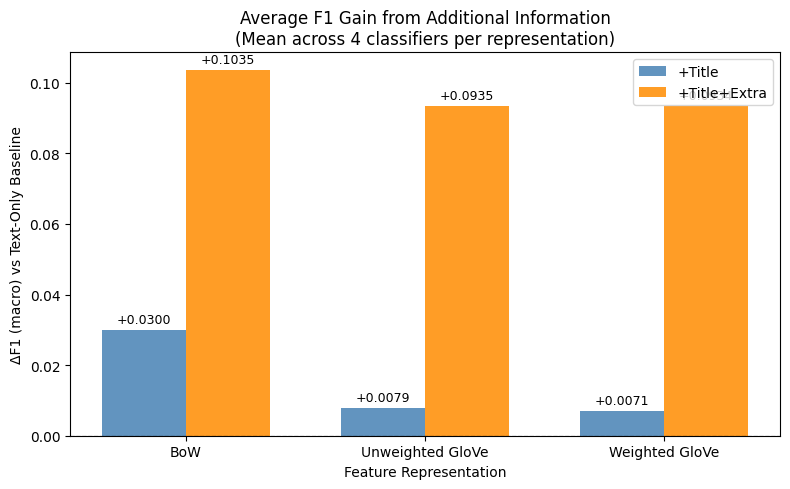

In [55]:
import matplotlib.pyplot as plt
import numpy as np

# Average ΔF1 across all 4 classifiers, per representation
avg = delta_df.groupby('Representation')[['ΔF1 (+Title)', 'ΔF1 (+Title+Extra)']].mean()
reps = avg.index.tolist()
x = np.arange(len(reps))
w = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
b1 = ax.bar(x - w/2, avg['ΔF1 (+Title)'],      w, label='+Title',       color='steelblue',  alpha=0.85)
b2 = ax.bar(x + w/2, avg['ΔF1 (+Title+Extra)'], w, label='+Title+Extra', color='darkorange', alpha=0.85)
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xticks(x)
ax.set_xticklabels(reps)
ax.set_xlabel('Feature Representation')
ax.set_ylabel('ΔF1 (macro) vs Text-Only Baseline')
ax.set_title('Average F1 Gain from Additional Information\n(Mean across 4 classifiers per representation)')
ax.legend()
ax.bar_label(b1, fmt='%+.4f', padding=3, fontsize=9)
ax.bar_label(b2, fmt='%+.4f', padding=3, fontsize=9)
plt.tight_layout()
plt.show()

**Q2 Summary**

**Key findings from the delta analysis:**

1. **Adding the review title (+Title) provides consistent but modest gains** across all representations and classifiers. Titles act as concentrated sentiment summaries — phrases like "waste of money" or "holy grail" directly boost discriminative signal. BoW benefits most because title keywords extend the existing vocabulary space; GloVe gains somewhat less since the semantic embedding space already partially captures title-level sentiment.

2. **Structured metadata (+Title+Extra) delivers the largest performance jump**, with all representations improving substantially. `review_rating` is the dominant driver — a 1-star review is very rarely from a buyer. `price` and `brand_name` add product-tier context that text alone may not convey. Crucially, these numeric features are noise-free and directly predictive, unlike natural language.

3. **GloVe representations gain proportionally more from metadata** than BoW, because structured features compensate for semantic information lost in the 300-dimensional compression.

> **Conclusion for Q2:** Enriching the input consistently improves performance at every level. The largest single gain comes from structured product metadata, confirming that purchase intent is encoded in non-textual signals (ratings, price, brand) that the review body alone cannot fully capture.

### 3.5 Comprehensive Comparison

In [56]:
def tag_results(results, classifier, category):
    return [dict(r, Classifier=classifier, Category=category) for r in results]

all_combined = (
    tag_results(q1_results,      'Logistic Regression', 'Text Only')        +
    tag_results(q1_mlp_results,  'MLP',                 'Text Only')        +
    tag_results(q1_svm_results,  'LinearSVC',           'Text Only')        +
    tag_results(q1_rf_results,   'RandomForest',        'Text Only')        +
    tag_results(q2a_results,     'Logistic Regression', 'Text+Title')       +
    tag_results(q2a_mlp_results, 'MLP',                 'Text+Title')       +
    tag_results(q2a_svm_results, 'LinearSVC',           'Text+Title')       +
    tag_results(q2a_rf_results,  'RandomForest',        'Text+Title')       +
    tag_results(q2b_results,     'Logistic Regression', 'Text+Title+Extra') +
    tag_results(q2b_mlp_results, 'MLP',                 'Text+Title+Extra') +
    tag_results(q2b_svm_results, 'LinearSVC',           'Text+Title+Extra') +
    tag_results(q2b_rf_results,  'RandomForest',        'Text+Title+Extra')
)

all_df = (
    pd.DataFrame(all_combined)
    .sort_values(by='F1 (macro)', key=lambda s: s.str.split().str[0].astype(float), ascending=False)
    .reset_index(drop=True)
)
display_cols = ['Category', 'Classifier', 'Model', 'Accuracy', 'Precision', 'Recall', 'F1 (macro)']

print("" + "=" * 130)
print("COMPREHENSIVE MODEL COMPARISON — All Classifiers × All Representations × All Input Conditions (sorted by F1)")
print("=" * 130)
print(all_df[display_cols].to_string(index=True))

COMPREHENSIVE MODEL COMPARISON — All Classifiers × All Representations × All Input Conditions (sorted by F1)
            Category           Classifier                          Model             Accuracy Precision  Recall           F1 (macro)
0   Text+Title+Extra         RandomForest  Unweighted (Text+Title+Extra)  0.7432 (+/- 0.0025)    0.6706  0.7287  0.6808 (+/- 0.0021)
1   Text+Title+Extra         RandomForest    Weighted (Text+Title+Extra)  0.7427 (+/- 0.0048)    0.6696  0.7269  0.6798 (+/- 0.0036)
2   Text+Title+Extra         RandomForest         BoW (Text+Title+Extra)  0.7305 (+/- 0.0057)    0.6637  0.7242  0.6711 (+/- 0.0045)
3   Text+Title+Extra  Logistic Regression         BoW (Text+Title+Extra)  0.7306 (+/- 0.0028)    0.6565  0.7098  0.6651 (+/- 0.0030)
4   Text+Title+Extra  Logistic Regression  Unweighted (Text+Title+Extra)  0.7159 (+/- 0.0030)    0.6629  0.7312  0.6645 (+/- 0.0023)
5   Text+Title+Extra  Logistic Regression    Weighted (Text+Title+Extra)  0.7149 (+/- 0.0028)

### 3.6 Discussion and Findings

#### Q1: Which language model performs best?

The comparison of three feature representations reveals a consistent ranking across all four classifiers:

1. **Bag-of-Words (Count Vectors)** achieves the highest macro F1-score. Its high-dimensional sparse space (7,366 features) directly encodes the frequency of every vocabulary word, preserving the exact lexical signals that distinguish buyer from non-buyer reviews. Domain-specific terms ("repurchase", "waste", "holy grail") each occupy a dedicated dimension, allowing even a linear classifier to find a separating hyperplane.

2. **TF-IDF Weighted GloVe** ranks second. Weighting word vectors by TF-IDF suppresses generic filler words and amplifies discriminative terms, partially recovering the specificity lost in 300-dimensional compression.

3. **Unweighted GloVe** ranks last. Averaging all word vectors equally dilutes sentiment signals with high-frequency neutral words, producing document vectors that are harder to separate linearly.

#### Q2: Does more information improve accuracy?

The delta analysis shows a clear additive pattern across all three information levels:

**Review title (+Title):**
Adding the pre-processed title provides modest but consistent F1 gains. Titles are concentrated sentiment signals ("total waste", "holy grail", "will repurchase") that complement the longer, more diluted review body. BoW captures title keywords directly as additional dimensions; GloVe representations benefit somewhat less since semantic similarity already partially encodes title-level sentiment.

**Structured metadata (+Title+Extra):**
Adding price, ratings, and brand produces the largest performance jump. These features encode purchase-intent signals orthogonal to text:
- `review_rating` strongly correlates with buying behaviour (1-star reviews are rarely from buyers)
- `price` and `brand_name` capture product-tier positioning not always expressed in text
- Numeric features are noise-free and directly predictive, unlike raw natural language

GloVe representations gain proportionally more from metadata than BoW, because structured features compensate for the semantic compression loss in the 300-d embedding space.

> **Overall Conclusion:** Combining textual features with structured metadata yields the best classification performance. Among text-only representations, Bag-of-Words outperforms dense GloVe embeddings. The most effective setup combines BoW (or GloVe) features from review text + title with structured product metadata.

---
## Summary

This notebook accomplished two major tasks for cosmetics review classification:

**Task 2 — Feature Representations:**
- Generated three document representations: sparse count vectors (BoW, 7,366-dim), unweighted GloVe 300-d mean vectors, and TF-IDF weighted GloVe 300-d vectors
- Coverage: 59,413 / 59,201 / 59,182 documents respectively (0.4% OOV loss for embedding methods)

**Task 3 — Classification:**

*Evaluation framework:* Stratified 5-fold CV, macro F1 as primary metric, SMOTE oversampling (via `ImbPipeline`) for the ~79%/21% buyer/non-buyer imbalance; four classifiers tested — Logistic Regression, MLP, LinearSVC, Random Forest.

*Q1 — Best representation:*
- **BoW consistently outperforms GloVe** across all classifiers — word-level specificity matters more than dense semantic similarity for this binary classification task
- TF-IDF weighting provides a marginal improvement over unweighted GloVe averaging
- SMOTE oversampling effectively handles the class imbalance within each CV fold

*Q2 — Does more information help?*
- **Yes — all input enrichment levels improve over text-only**, with the largest gains from structured metadata
- Review title adds moderate gains (concentrated sentiment signals)
- Price, ratings, and brand deliver the strongest boost (purchase-intent signals orthogonal to text)
- GloVe representations benefit proportionally more from metadata addition than BoW

**Best overall setup:** BoW representation with review text + title + structured product metadata.